# Credit Risk Modelling

Steps involved in data clearning for credit risk modelling with machine learning: 
- Gathering tha data 
- Data Quality/Data Cleaning 
- Developing the behaviourial scorecard (The machine learning/statistical model) 
- Using the model to predict scores (Credit rating)

The expectation will be for you to replicate the same adding important bits like :
- Doing extra exploratory data analysis and providing insights on any notable trends 
- Performing indepth data cleaning and providing explations on the steps and rationale behind the methodology used e.g when handling the missing values, why would you opt for deletion rather than imputation 
- Doing extra feature engineering and feature selction to improve the model performance. 
- Using alternative models and providing adequate justification for the same. 

## Libraries & Data import

In [39]:
# Data Explotation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     # Visualization
import seaborn as sns               # Advanced Visualization
import missingno as mn

In [40]:
# Loading data 
Loan = pd.read_csv(r"./data/raw-data.csv")

Loan.head(2)

C:\Users\HP\AppData\Local\Temp\ipykernel_4568\1724087143.py:2: DtypeWarning: Columns (0: V10, 1: V13, 2: V14, 3: V15, 4: V16) have mixed types. Specify dtype option on import or set low_memory=False.
  Loan = pd.read_csv(r"./data/raw-data.csv")


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0


In [41]:
#Renaming columns in the dataset with their correct names
Loan_renamed = Loan.rename(columns={
'V1': 'Customer ID',
'V2': 'Customer has bounced in first EMI', 
'V3': 'No of times bounced 12 months',
'V4': 'Maximum Months on Book (MOB)',
'V5': 'No of times bounced while repaying the loan',
'V6': 'Equated Monthly Installment (EMI)',
'V7': 'Loan Amount',
'V8': 'Tenure',
'V9': 'Dealer codes from where customer has purchased the Two wheeler',
'V10': 'Product code of Two wheeler', 
'V11': 'No of advance EMI paid',
'V12': 'Rate of interest',
'V13': 'Gender',
'V14': 'Employment type',
'V15': 'Resident type of customer',
'V16': 'Date of birth',
'V17': 'Customer age when loan was taken',
'V18': 'No of loans',
'V19': 'No of secured loans',
'V20': 'No of unsecured loans',
'V21': 'Max amount sanctioned in the Live loans',
'V22': 'No of new loans in last 3 months',
'V23': 'Total sanctioned amount in the secured Loans which are Live',
'V24': 'Total sanctioned amount in the unsecured Loans which are Live',
'V25': 'Maximum amount sanctioned for any Two wheeler loan',
'V26': 'Time since last Personal loan taken (in months)',
'V27': 'Time since first consumer durables loan taken (in months)',
'V28': 'No of times 30 days past due in last 6 months',
'V29': 'No of times 60 days past due in last 6 months',
'V30': 'No of times 90 days past due in last 3 months',
'V31': 'Tier',
'V32': 'Target variable'})

Loan_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column                                                          Non-Null Count   Dtype  
---  ------                                                          --------------   -----  
 0   Customer ID                                                     119528 non-null  int64  
 1   Customer has bounced in first EMI                               119528 non-null  int64  
 2   No of times bounced 12 months                                   119528 non-null  int64  
 3   Maximum Months on Book (MOB)                                    85048 non-null   float64
 4   No of times bounced while repaying the loan                     85048 non-null   float64
 5   Equated Monthly Installment (EMI)                               85048 non-null   float64
 6   Loan Amount                                                     85048 non-null   float64
 7   Tenure                                           

## Basic EDA & Data Cleaning

### Missingness

<Axes: >

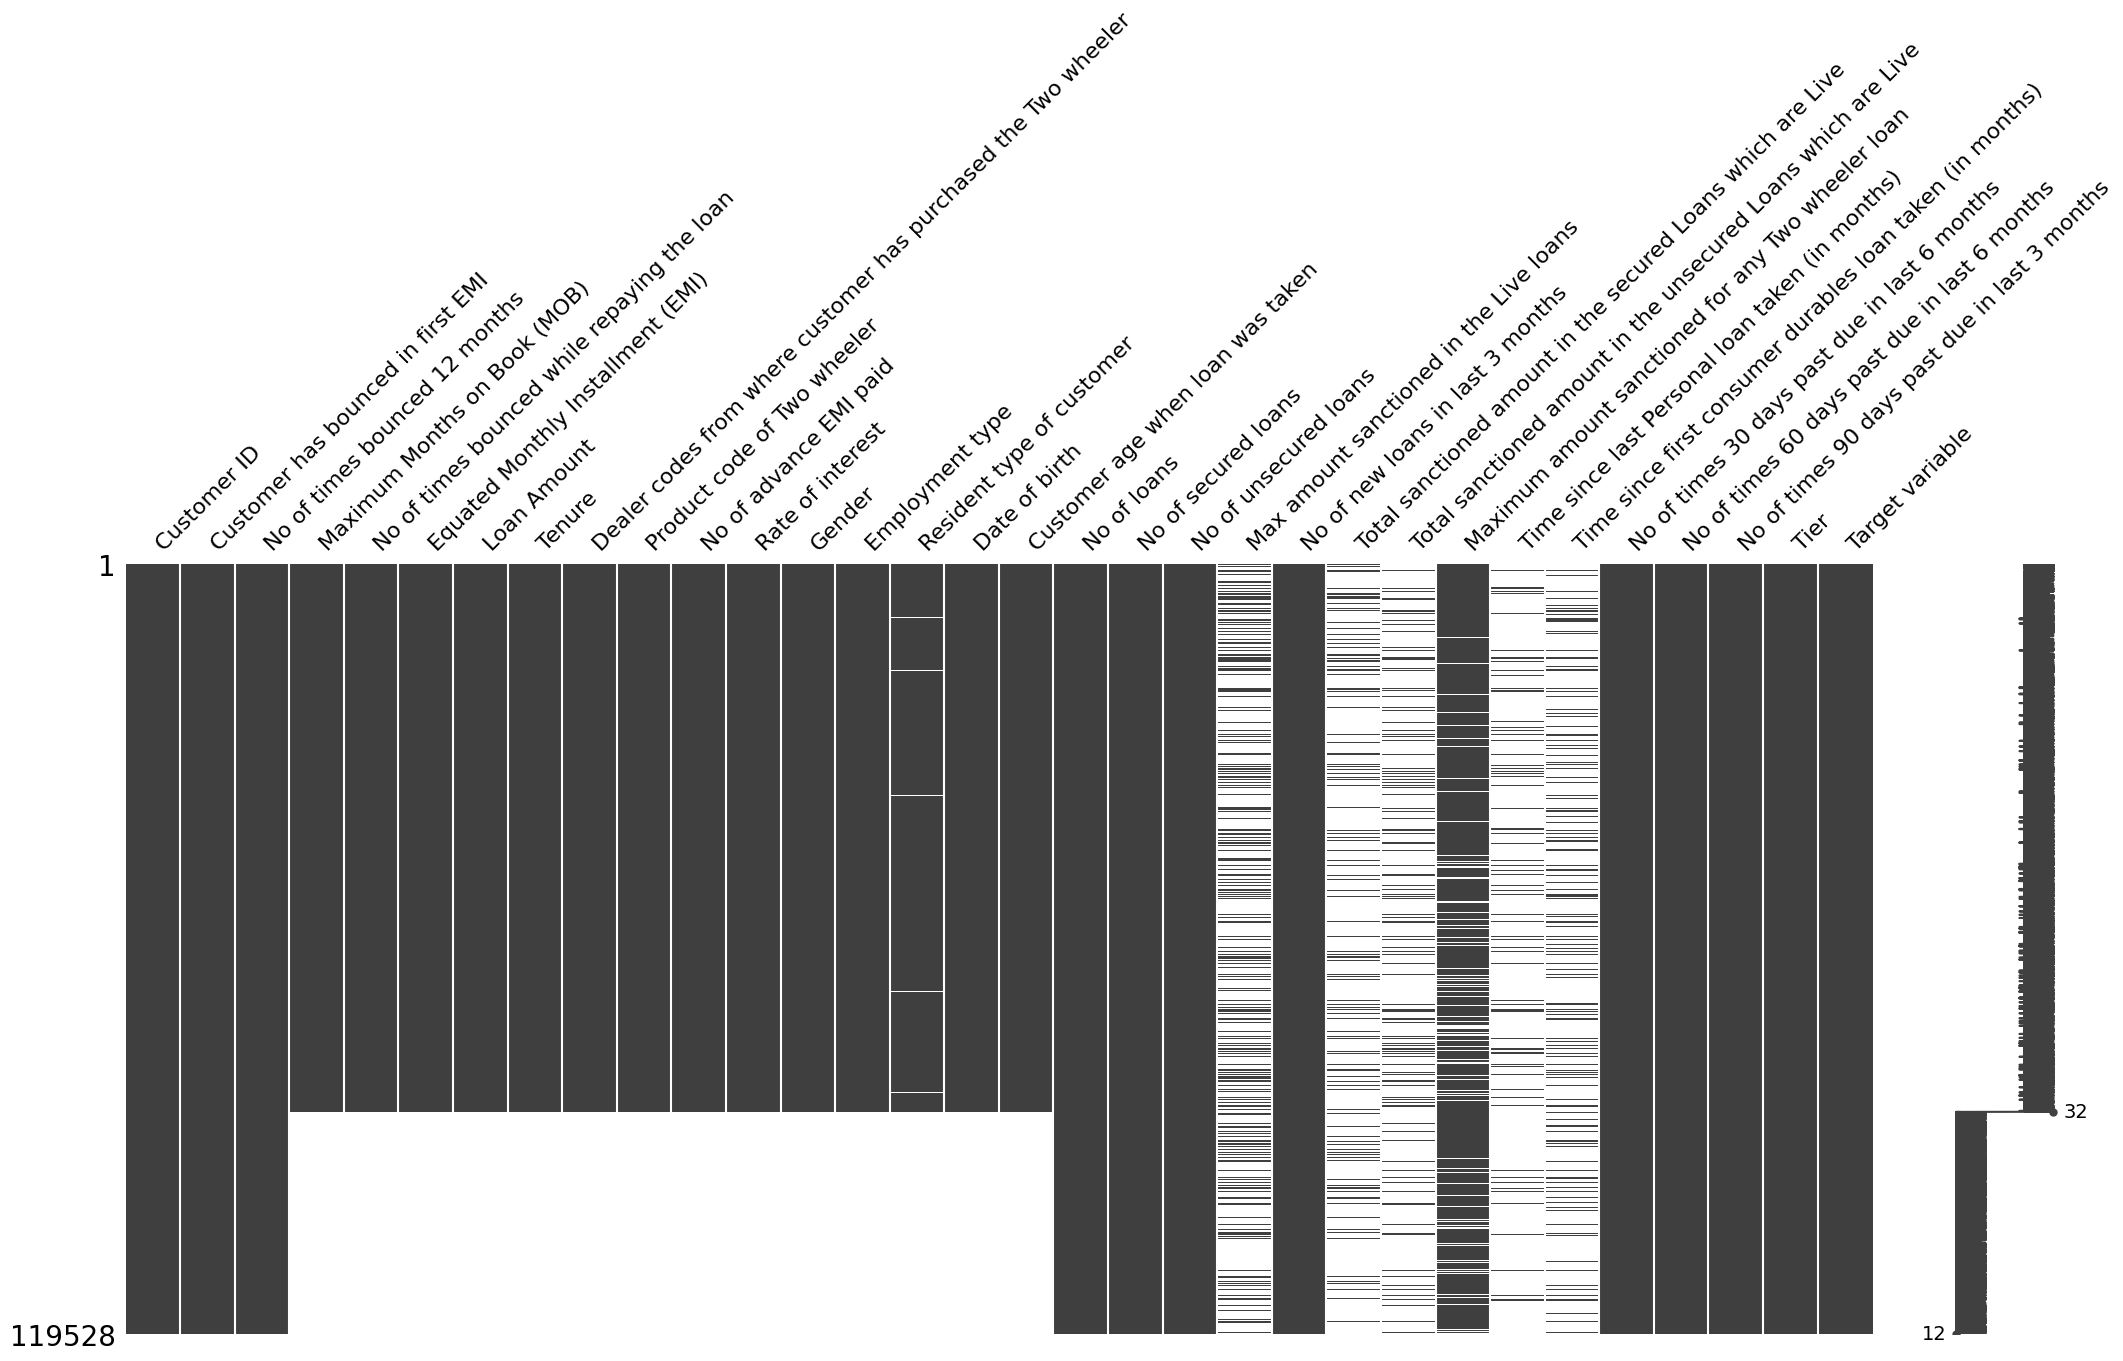

In [ ]:
mn.matrix(Loan_renamed)

Conclusion: 

<Axes: >

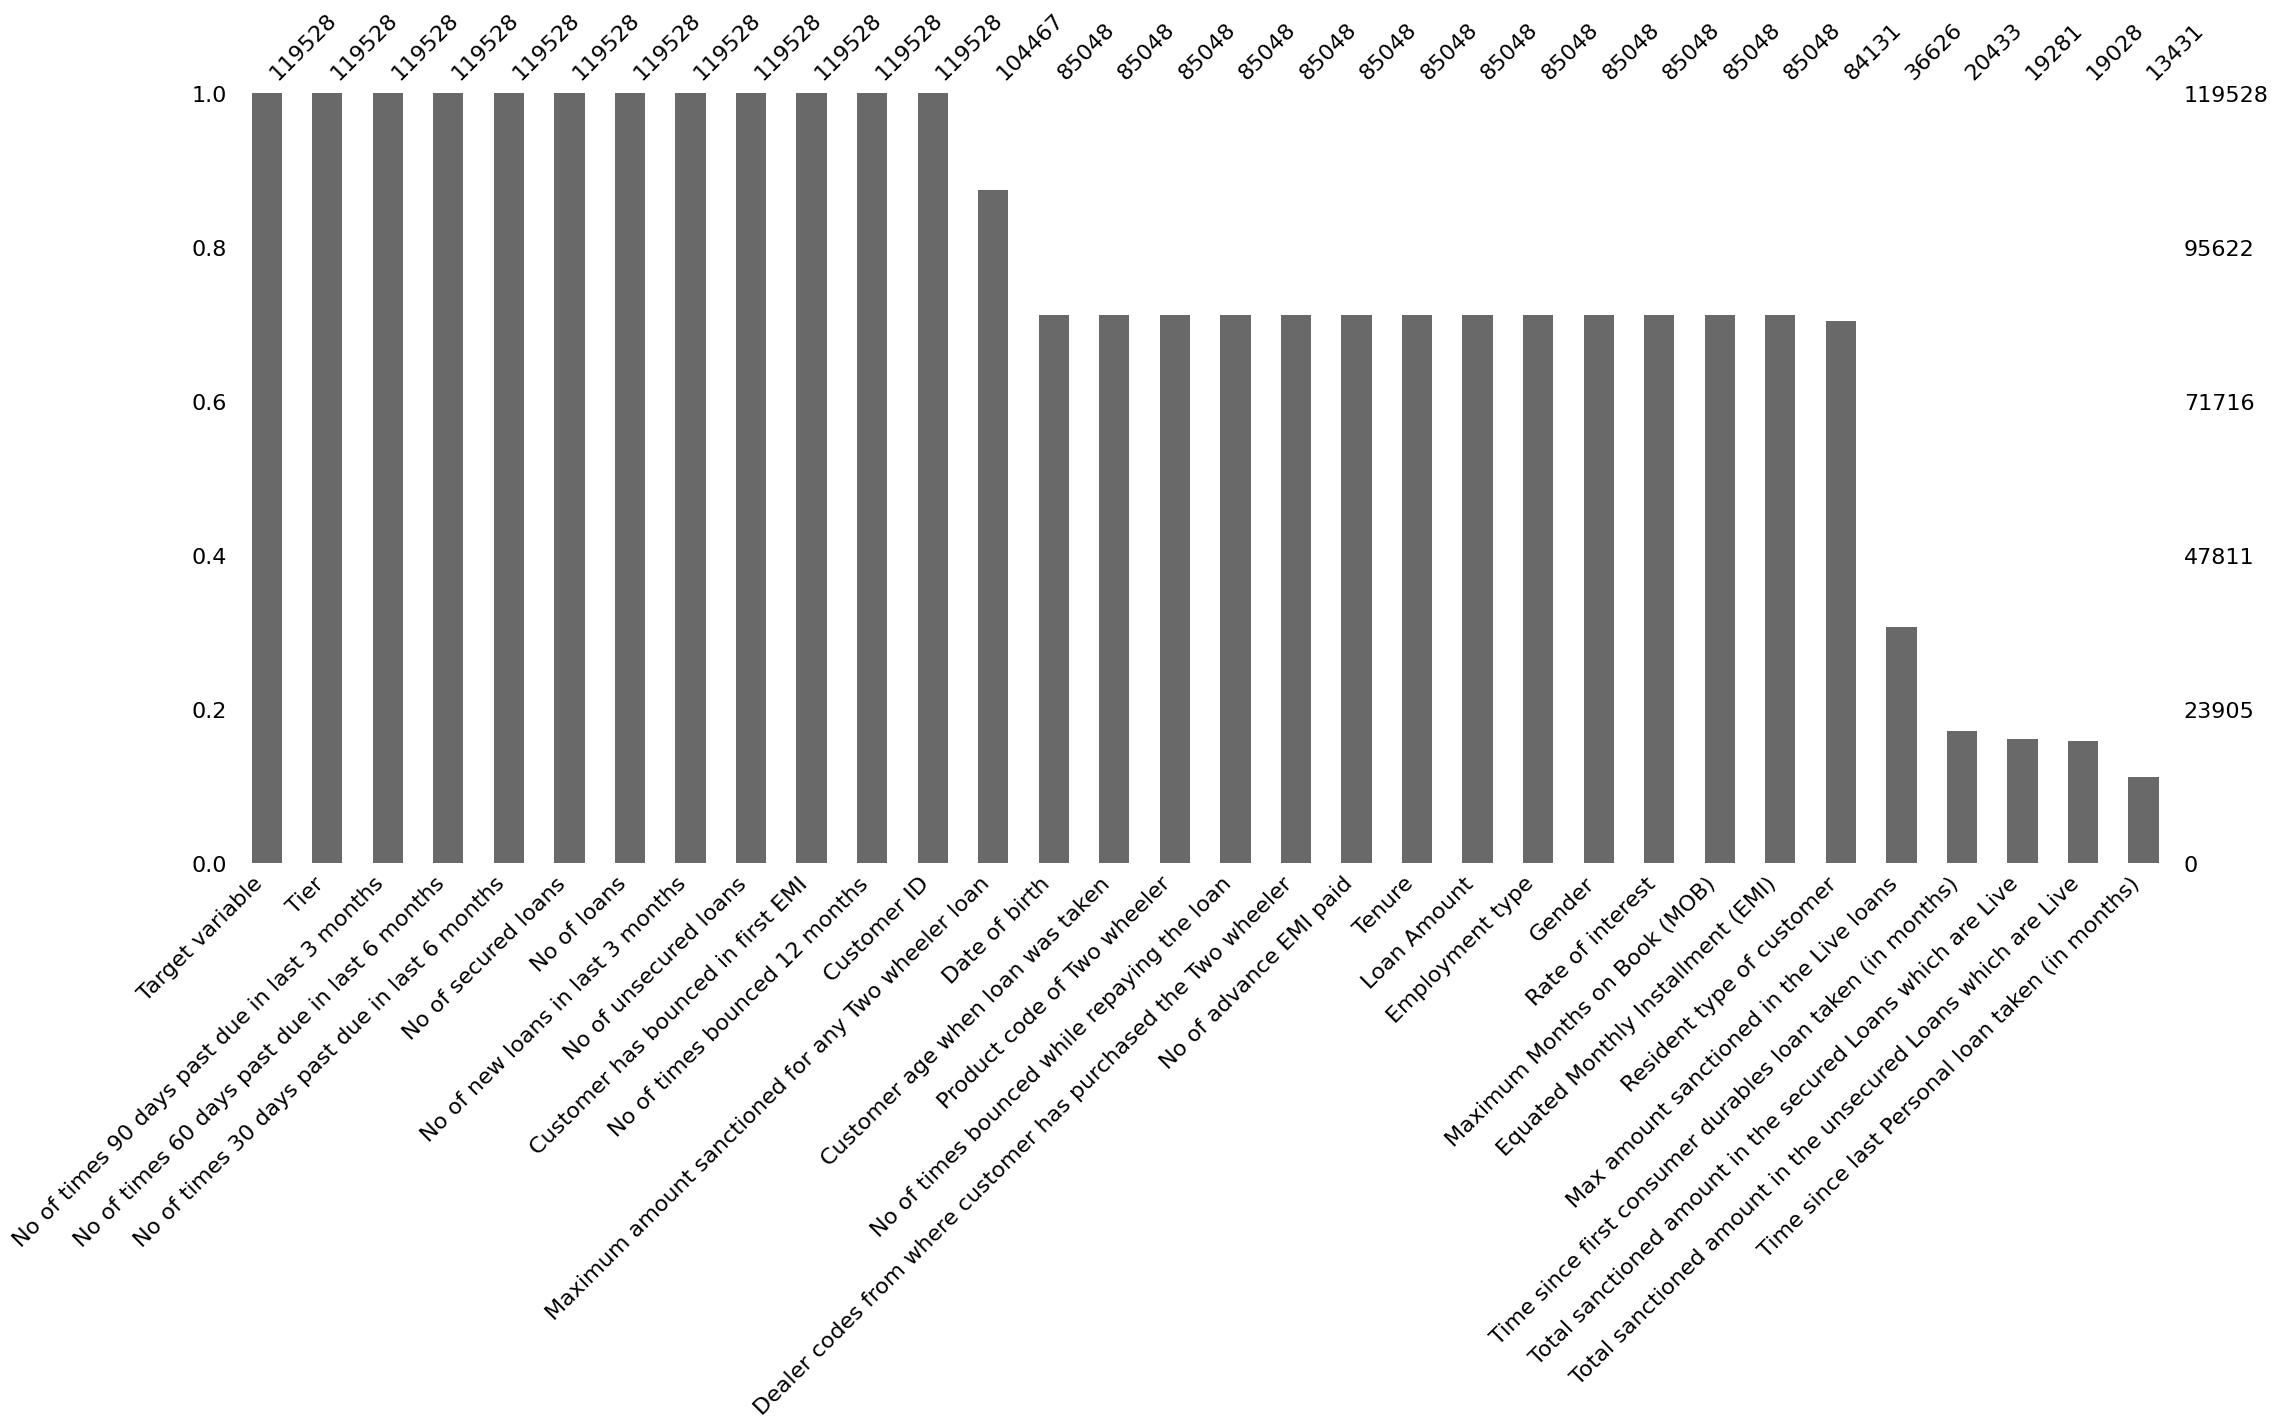

In [9]:
mn.bar(Loan_renamed, sort='descending')

Conclusion: 

<Axes: >

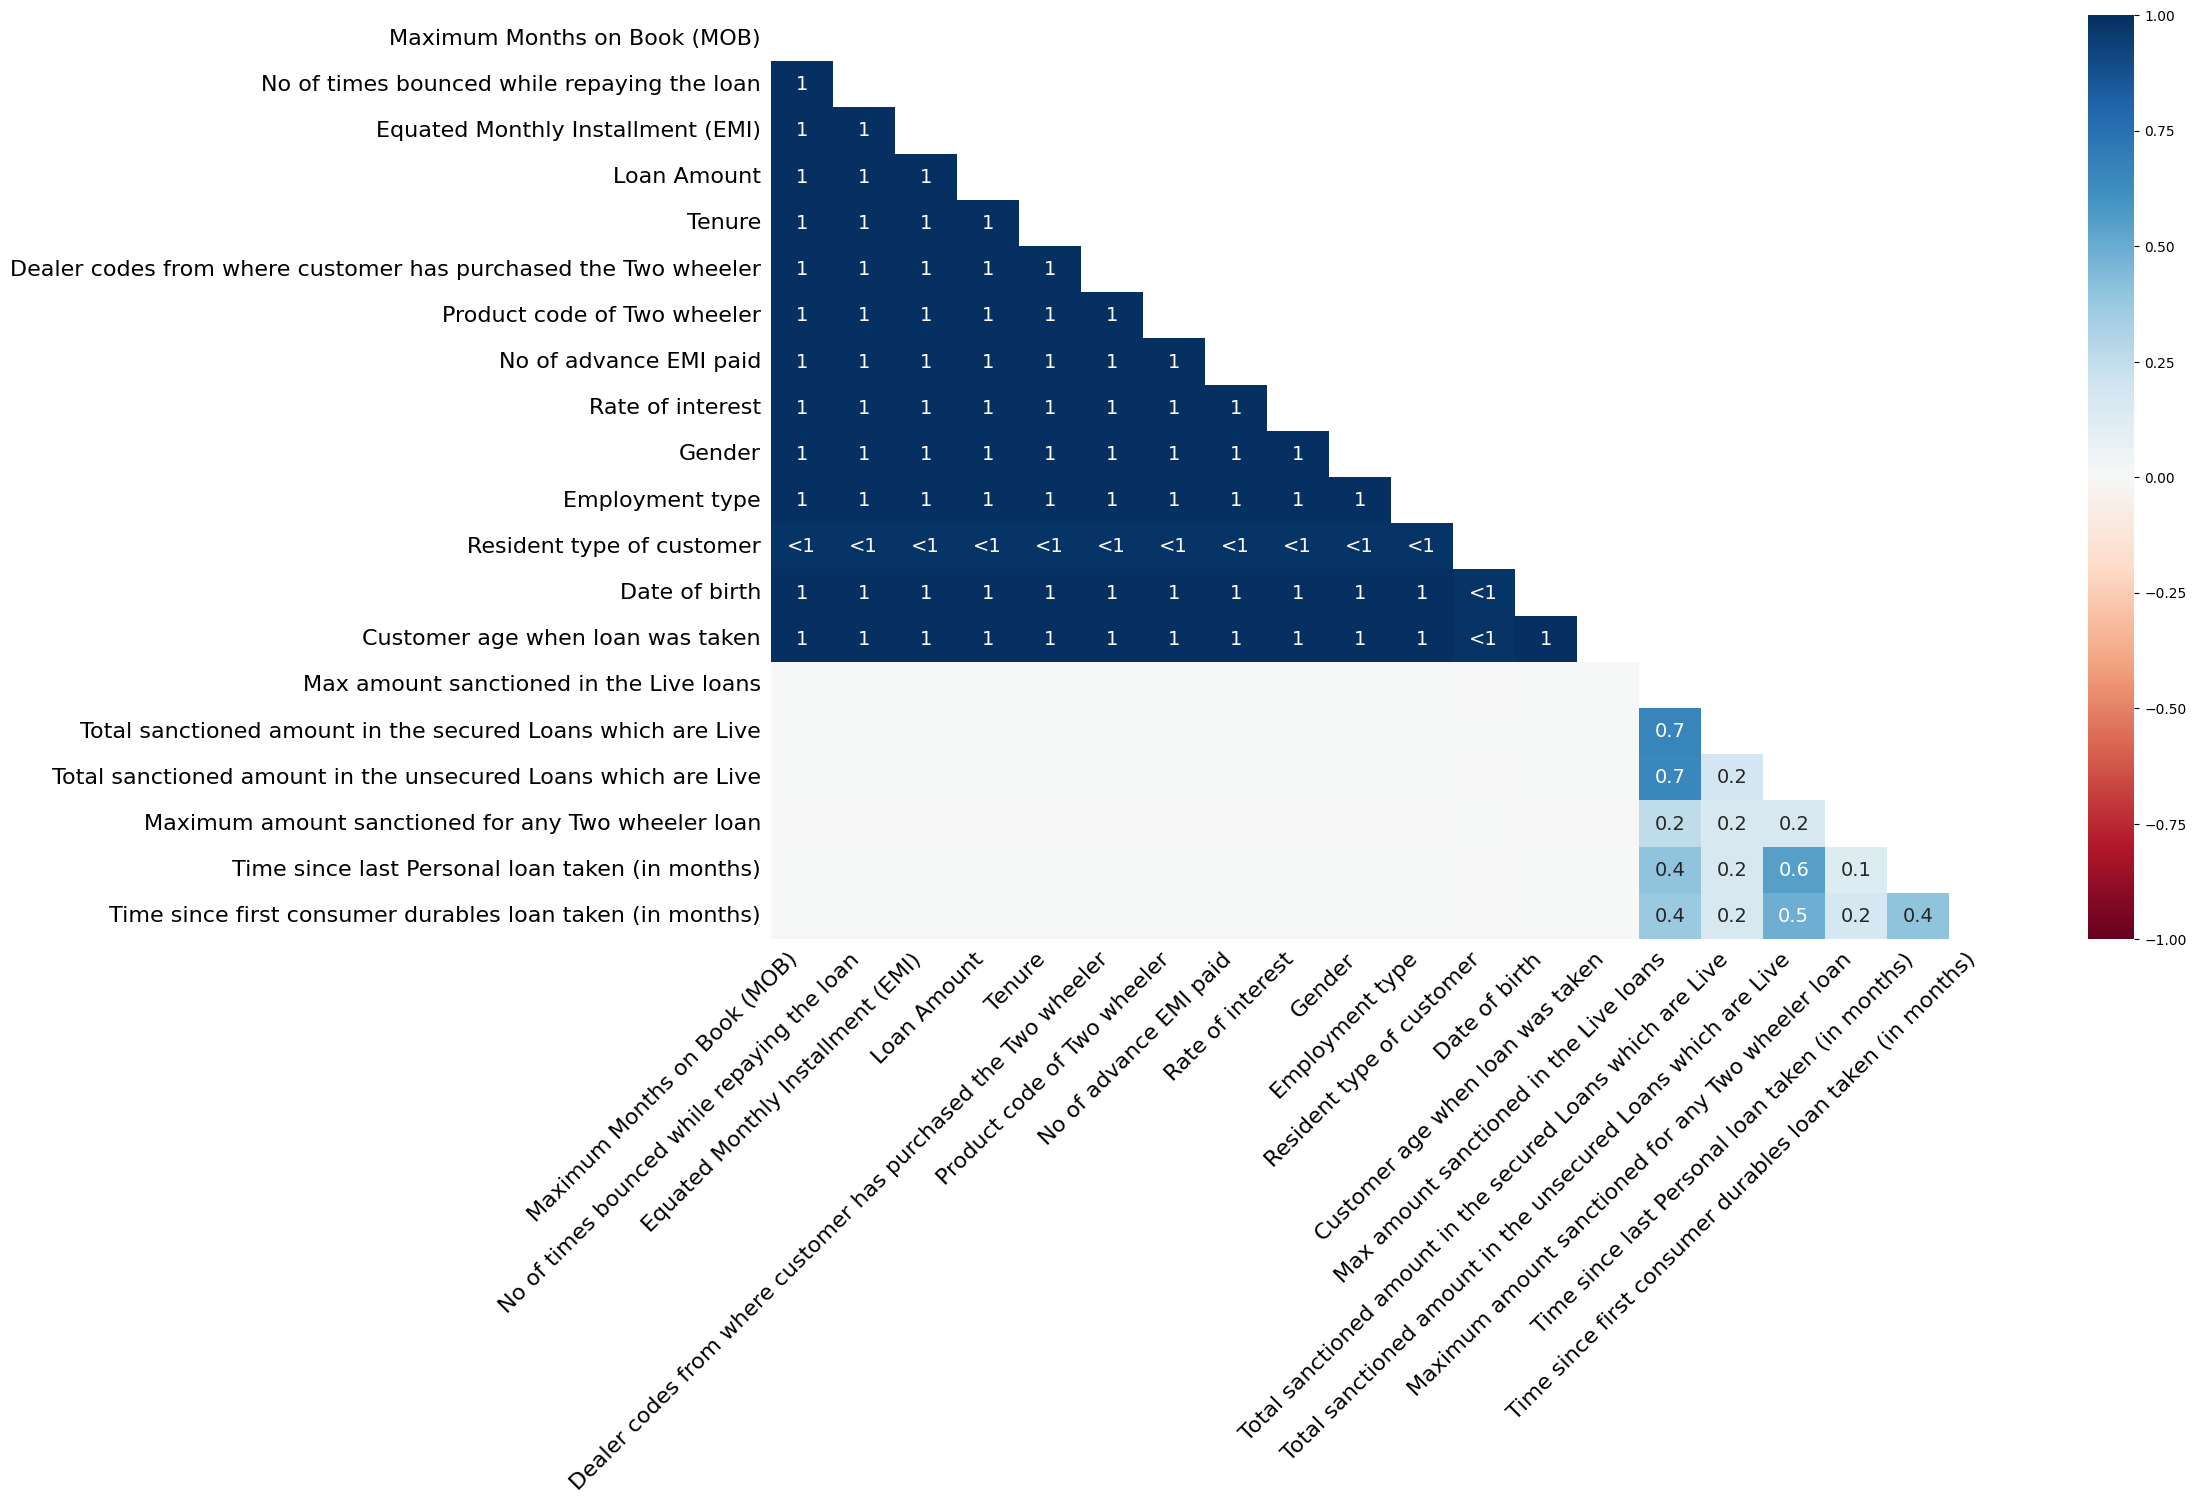

In [6]:
mn.heatmap(Loan_renamed)

Conclusion: 

<Axes: >

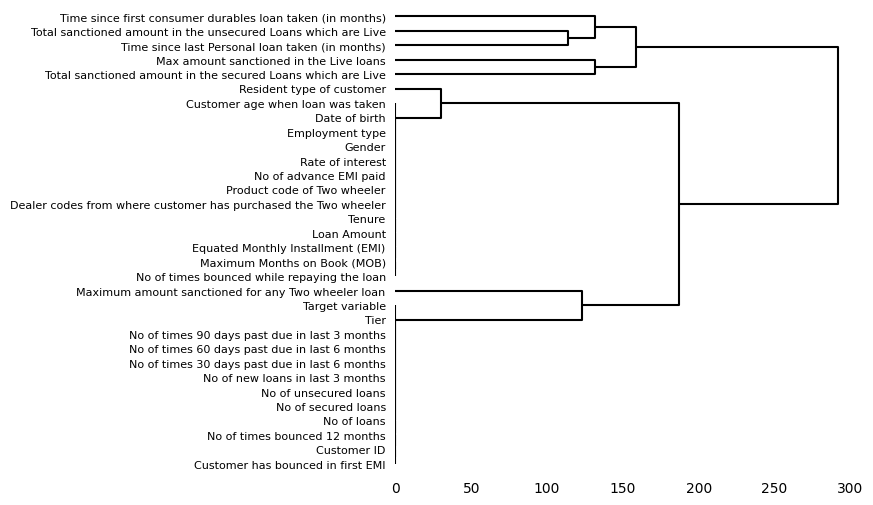

In [24]:
mn.dendrogram(Loan_renamed,
              orientation='right',
              figsize=(6, 6),
              fontsize=8)

Conclusion: 

#### Handling Missingness

In [25]:
# check for duplicates
Loan_renamed.duplicated().sum()

np.int64(0)

### Class imbalance

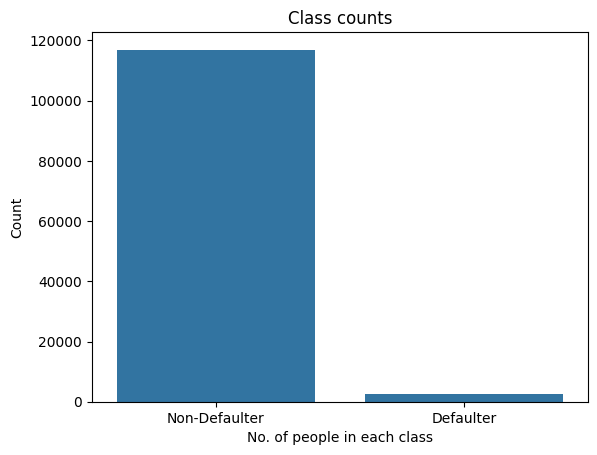

Target variable
0    116914
1      2614
Name: count, dtype: int64


In [26]:
# distribution of target variable

plt.figure()
sns.countplot(x='Target variable',
              data=Loan_renamed)
plt.xticks((0, 1),
           ["Non-Defaulter", "Defaulter"])
plt.xlabel("No. of people in each class")
plt.ylabel("Count")
plt.title("Class counts",
          y=1)
plt.show()

print(Loan_renamed['Target variable'].value_counts())

#### Distributions

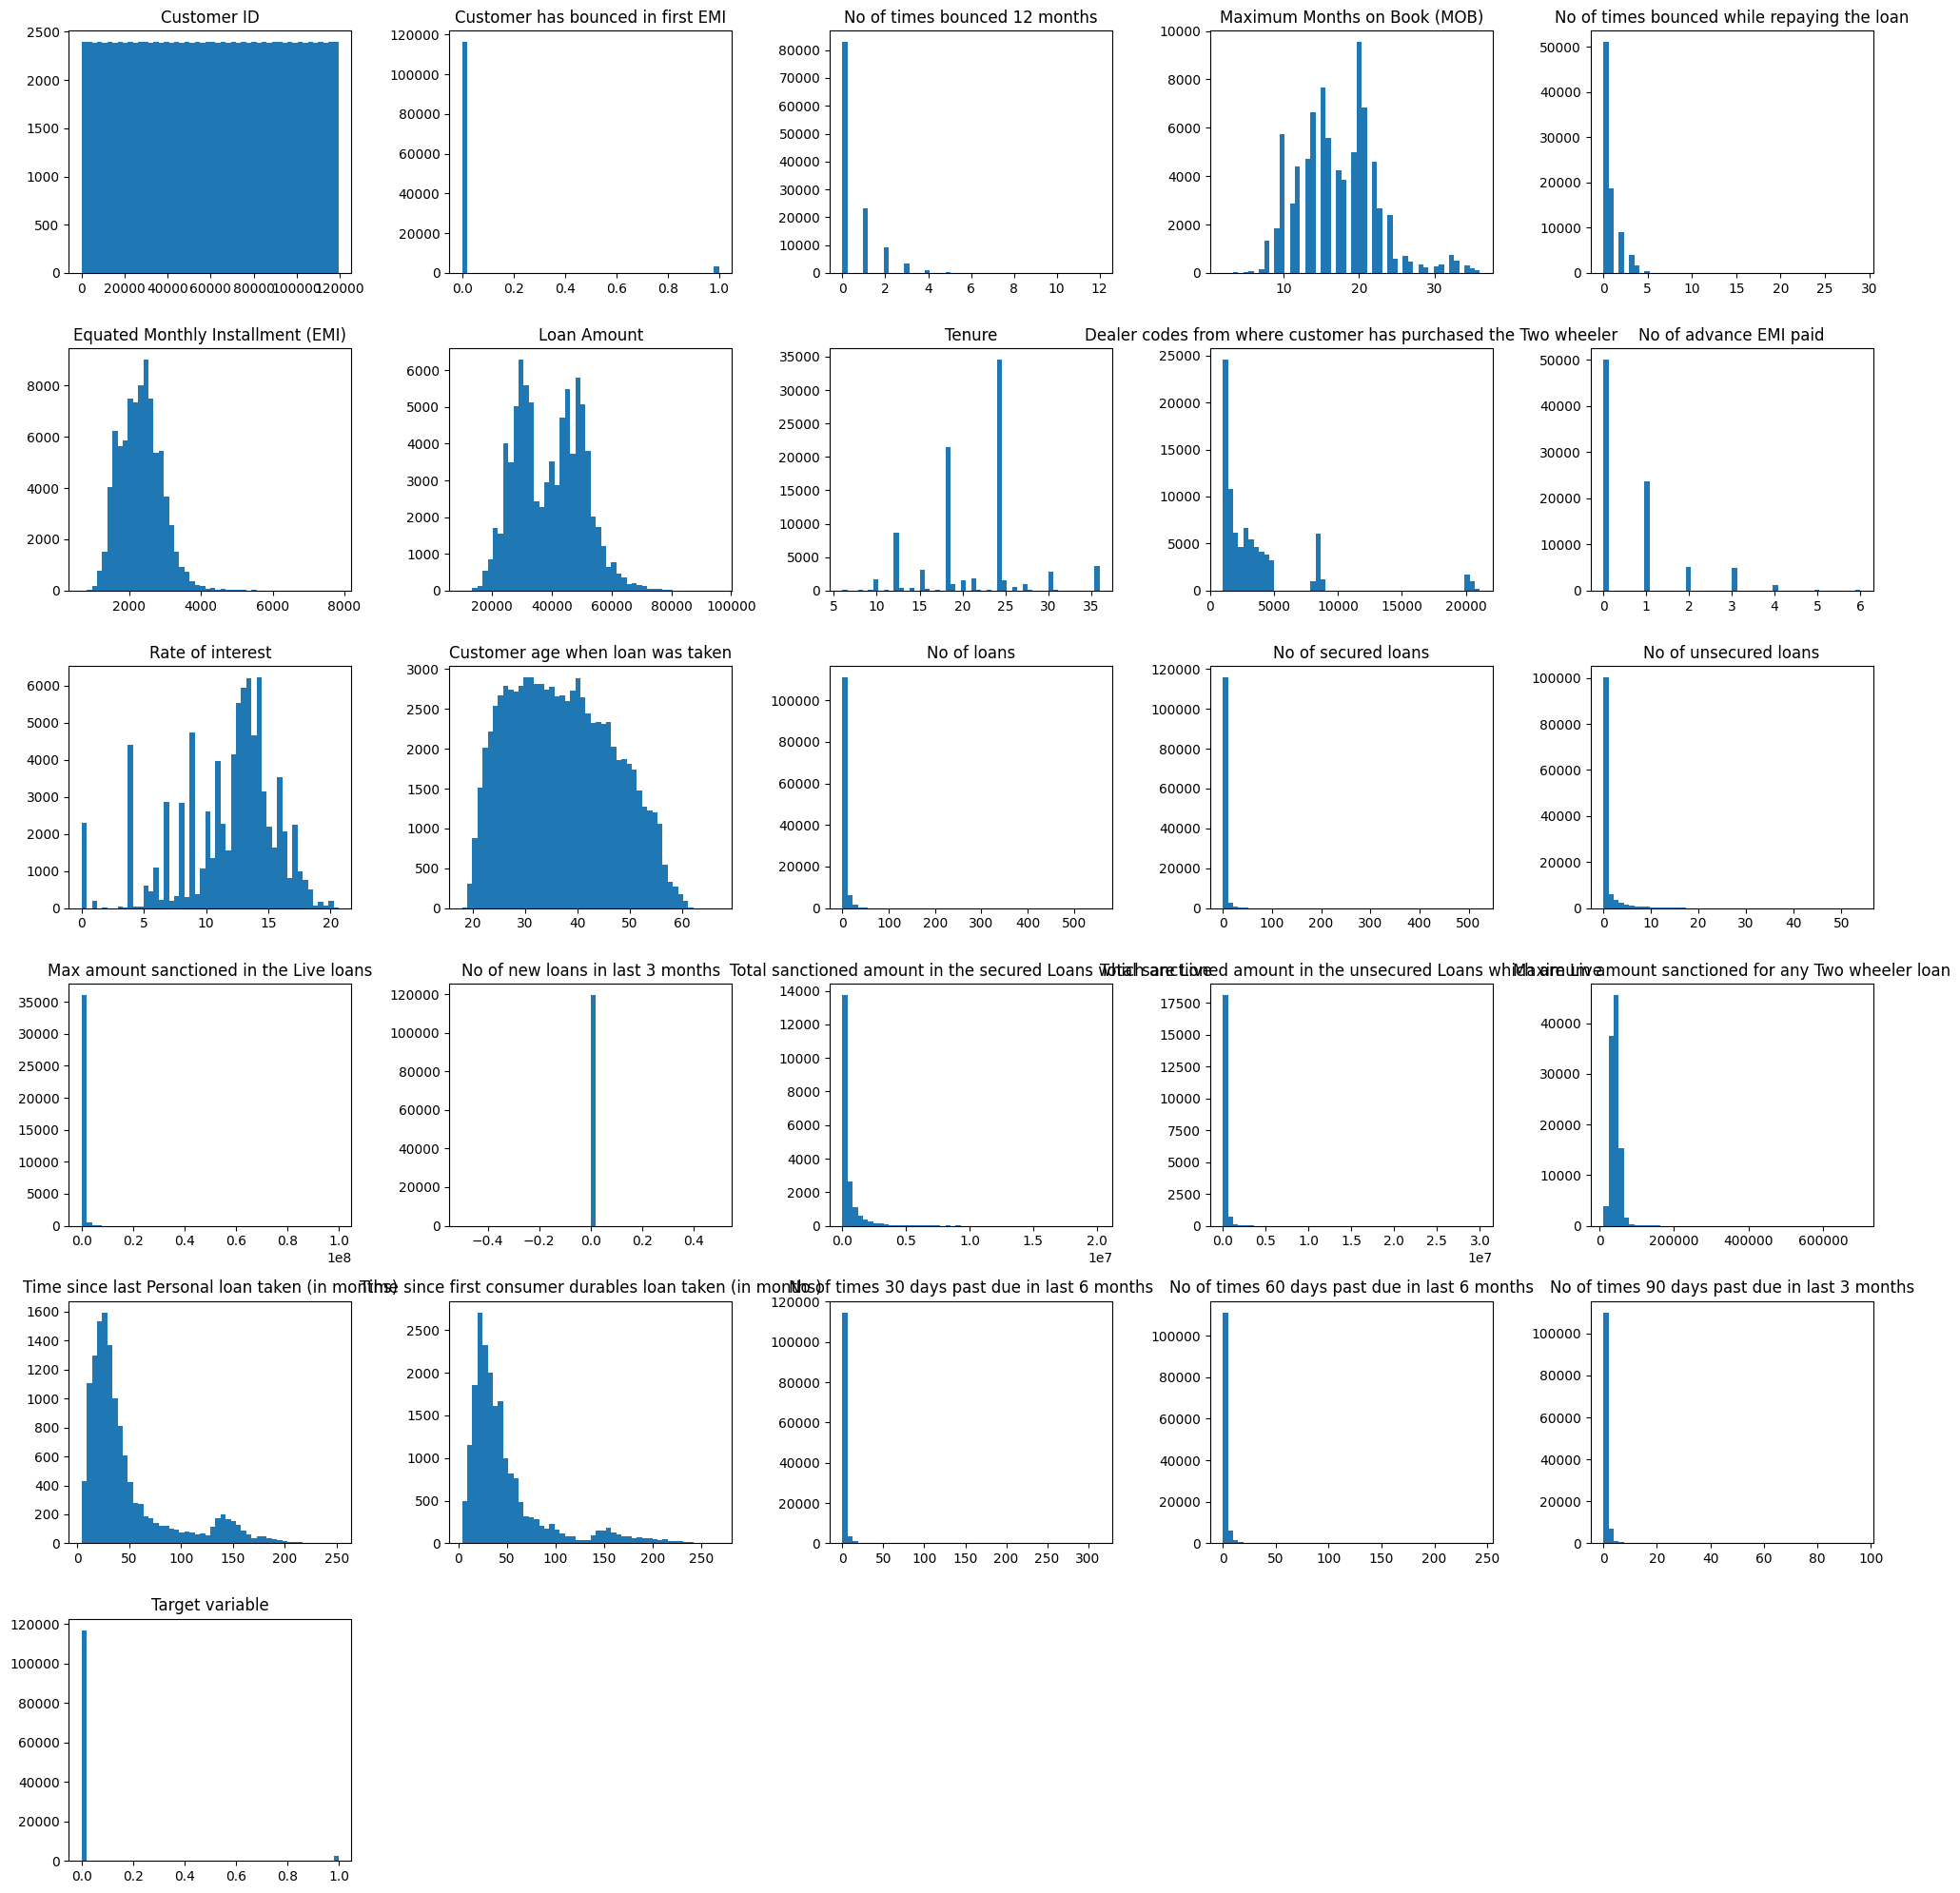

In [35]:
Loan_renamed.hist(figsize=(20,20),
                  grid=False,
                  bins=50)
plt.title('Feature Distributions')
plt.tight_layout()
plt.show()

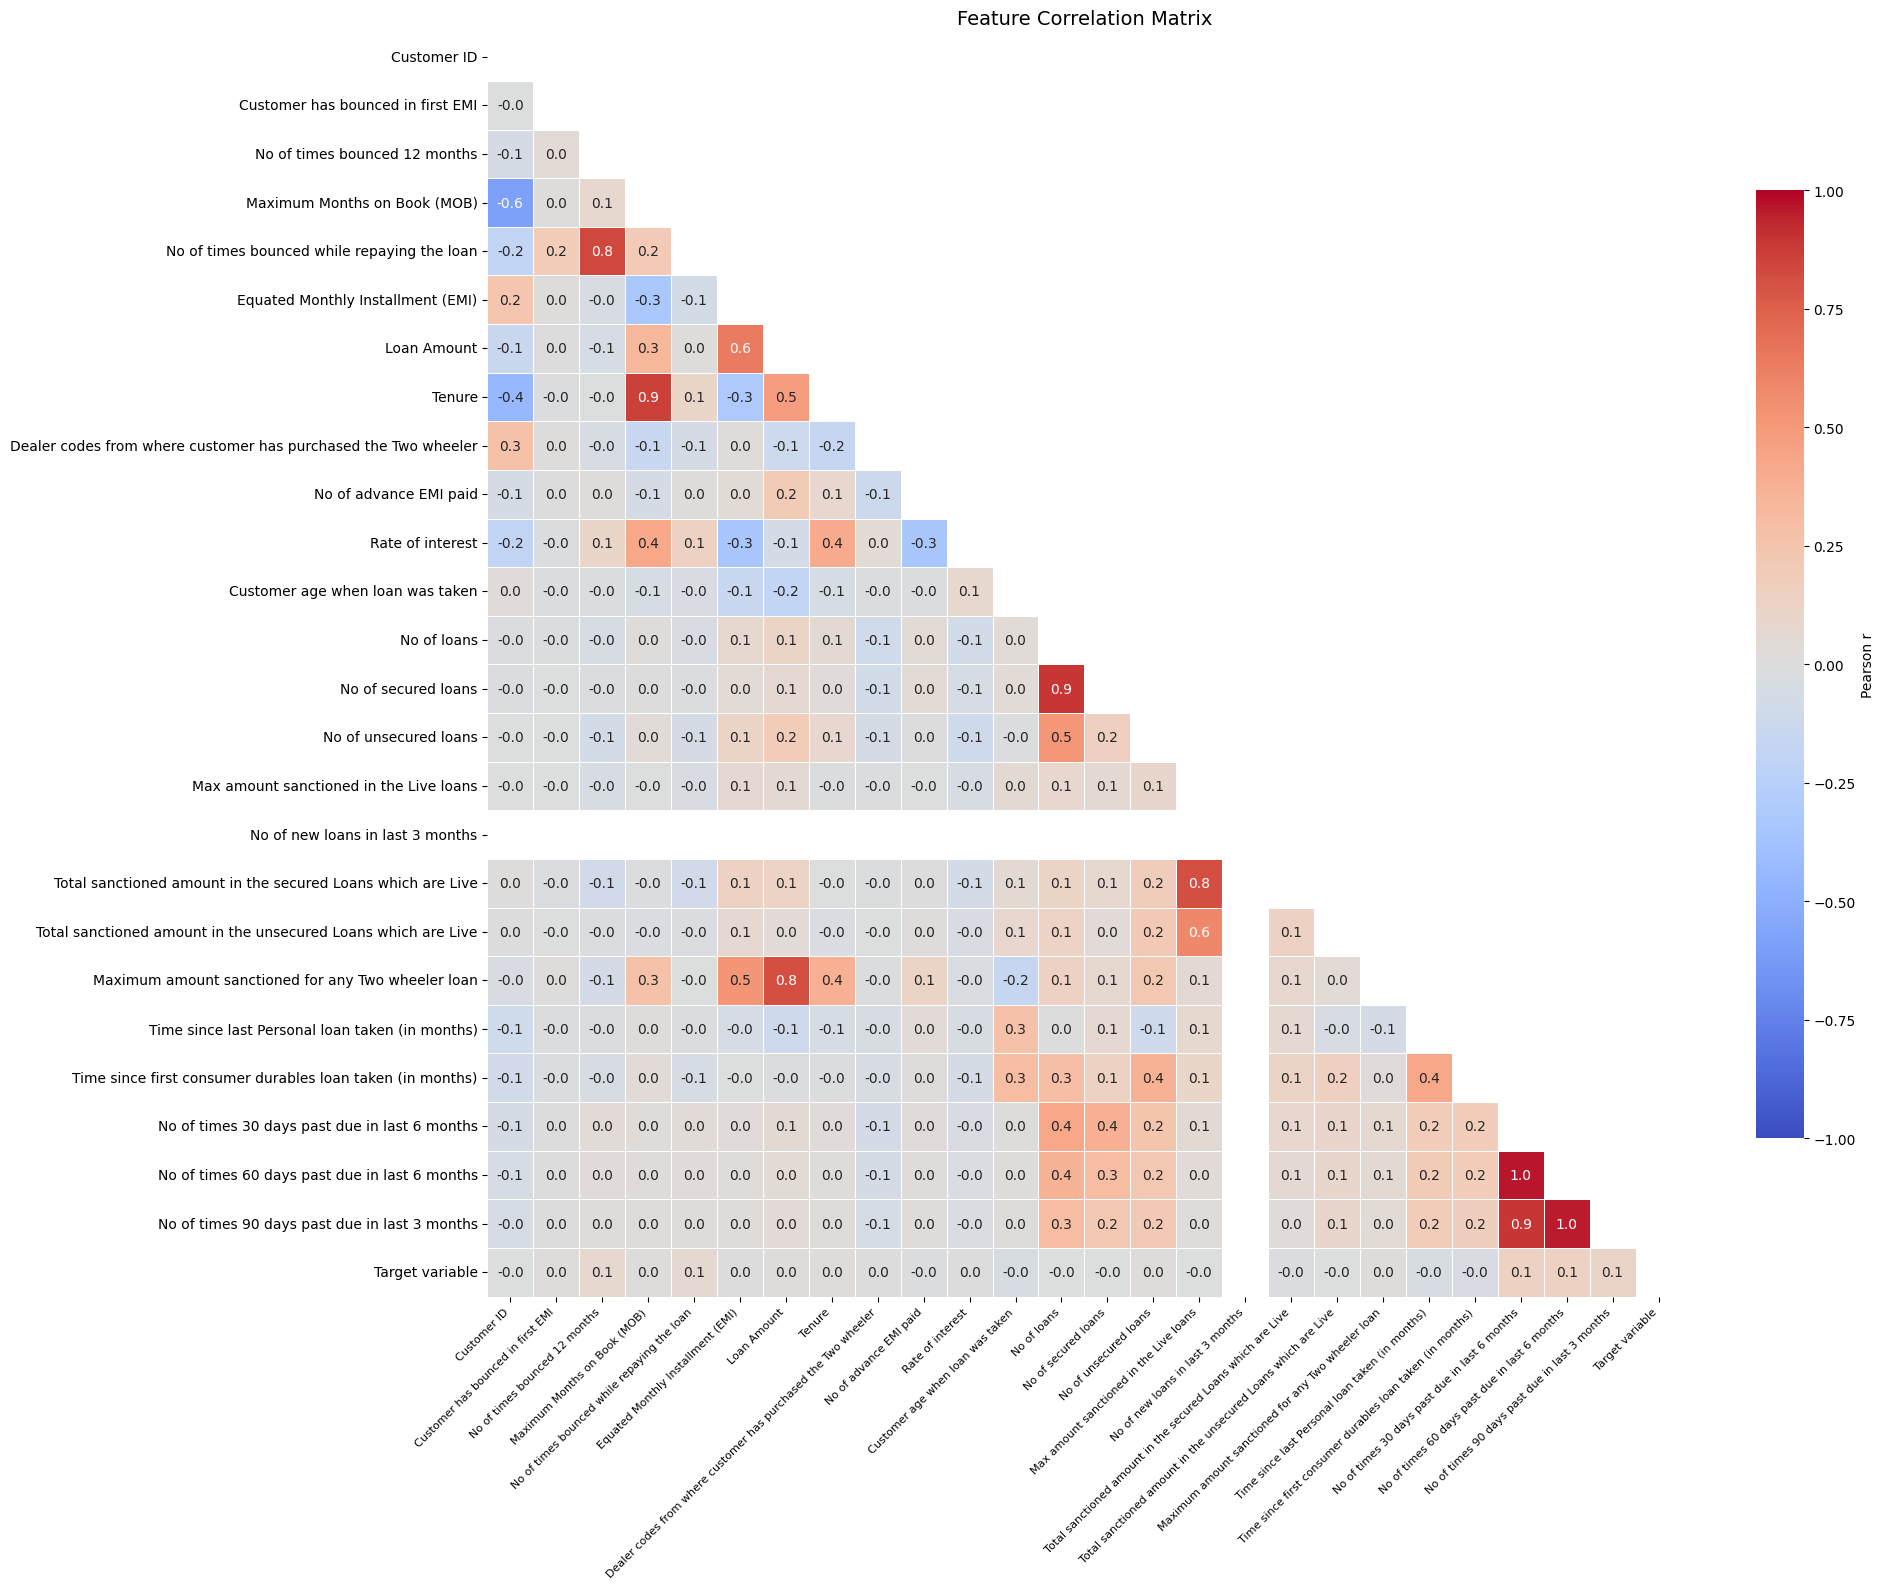

In [ ]:
# correlation matrix for numerical features
numeric_df = Loan_renamed.select_dtypes(include=np.number)

corrmat = numeric_df.corr()
mask = np.triu(np.ones_like(corrmat, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corrmat,
            mask=mask,
            cmap="coolwarm",   
            center=0,          
            vmin=-1,
            vmax=1,
            annot=True,        
            fmt=".1f",         
            linewidths=0.4,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"},
            ax=ax)

ax.set_title("Numerical Features' Correlations",
             fontsize=14,)
plt.xticks(rotation=45,
           ha="right",
           fontsize=8)
plt.yticks()

plt.tight_layout()
plt.show()

The data set is pretty imbalanced as expected where positive examples defualters are significanltly less than 25%. We'll explain in the next section how to handle all of them after giving an overview of ensemble methods.

<font color='white'>For the three plots about LOAN AMOUNT, you could indicate why each is significant and what insights it gives that are different from the other or maybe what it adds on.</font>

## Modelling

In [ ]:
X = Loan_renamed.drop('Target variable', axis=1)
y = Loan_renamed[['Target variable']]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=20)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)